In [1]:
%pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.9 MB/s eta 0:00:00


In [2]:
import numpy as np # type: ignore
import torch # type: ignore
import matplotlib.pyplot as plt # type: ignore
import networkx as nx # type: ignore

from torch_geometric.data import Data # type: ignore
from torch_geometric.utils import to_networkx, to_dense_adj # type: ignore

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch version:", torch.__version__)
print("PyTorch Geometric version:", torch.__version__)

PyTorch version: 2.10.0+cpu
PyTorch Geometric version: 2.10.0+cpu


In [3]:
def make_sbm_graph(n_nodes, block_sizes, p_intra, p_inter):
    """Generates a snapshot of a stochastic block model."""
    sizes = block_sizes
    probs = [
        [p_intra if i == j else p_inter for j in range(len(block_sizes))]
        for i in range(len(block_sizes))
    ]
    return nx.stochastic_block_model(sizes, probs, seed=SEED)

In [4]:
def evolve_graph(G_prev, p_remove, p_add):
    """Evolves a graph with separate probabilities for adding and removing edges."""
    G_new = G_prev.copy()
    nodes = list(G_prev.nodes())

    for i in nodes:
        for j in nodes:
            if i < j:
                if G_prev.has_edge(i, j):
                    if np.random.rand() < p_remove:
                        G_new.remove_edge(i, j)
                else:
                    if np.random.rand() < p_add:
                        G_new.add_edge(i, j)
    return G_new

In [5]:
# def generate_sequence(n_nodes, block_sizes, p_intra, p_inter, p_flip, T):
#     """
#     Generates a sequence of evolving graphs
#     """
#     G0 = make_sbm_graph(n_nodes, block_sizes, p_intra, p_inter)
#     sequence = [G0]
#     for _ in range(T -1):
#         G_next = evolve_graph(sequence[-1], p_flip)
#         sequence.append(G_next)
#     return sequence

In [6]:
def graph_to_pyg(G, n_nodes):
    """Converts a NetworkX graph into a PyTorch Geometric Data object."""
    degrees = dict(G.degree())
    x = torch.tensor(
        [[degrees.get(i, 0)] for i in range(n_nodes)],
        dtype=torch.float
    )

    edges = list(G.edges())
    if len(edges) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        src = [u for u, v in edges] + [v for u, v in edges]
        dst = [v for u, v in edges] + [u for u, v in edges]
        edge_index = torch.tensor([src, dst], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, num_nodes=n_nodes)

In [7]:
def generate_dataset(n_sequences, n_nodes, block_sizes,
                     p_intra, p_inter, p_remove, p_add, T):
    """Generates independent evolving graph sequences."""
    all_sequences = []
    all_pairs = []

    for seq_idx in range(n_sequences):
        G0 = make_sbm_graph(n_nodes, block_sizes, p_intra, p_inter)
        sequence = [G0]
        for t in range(T - 1):
            G_next = evolve_graph(sequence[-1], p_remove, p_add)
            sequence.append(G_next)

        all_sequences.append(sequence)
        pyg_sequence = [graph_to_pyg(G, n_nodes) for G in sequence]
        for t in range(T - 1):
            all_pairs.append((pyg_sequence[t], pyg_sequence[t + 1]))

    return all_sequences, all_pairs

In [8]:
N_NODES     = 20
BLOCK_SIZES = [10, 10]
P_INTRA     = 0.7
P_INTER     = 0.05
P_REMOVE    = 0.15    # existing edges removed with 15% chance
P_ADD       = 0.05    # non-edges added with 5% chance. Equilibrium density ≈ 0.05 / (0.05 + 0.15) = 0.25
T           = 20
N_SEQ       = 50      # 50 independent sequences → 50×19 = 950 training pairs

all_sequences, all_pairs = generate_dataset(
    N_SEQ, N_NODES, BLOCK_SIZES,
    P_INTRA, P_INTER, P_REMOVE, P_ADD, T
)

seq0 = all_sequences[0]
print("Edge counts in sequence 0:")
for t in [0, 5, 10, 15, 19]:
    print(f"  t={t:2d} → {seq0[t].number_of_edges()} edges")

print(f"\nTotal (input, target) training pairs: {len(all_pairs)}")

Edge counts in sequence 0:
  t= 0 → 71 edges
  t= 5 → 63 edges
  t=10 → 49 edges
  t=15 → 53 edges
  t=19 → 51 edges

Total (input, target) training pairs: 950


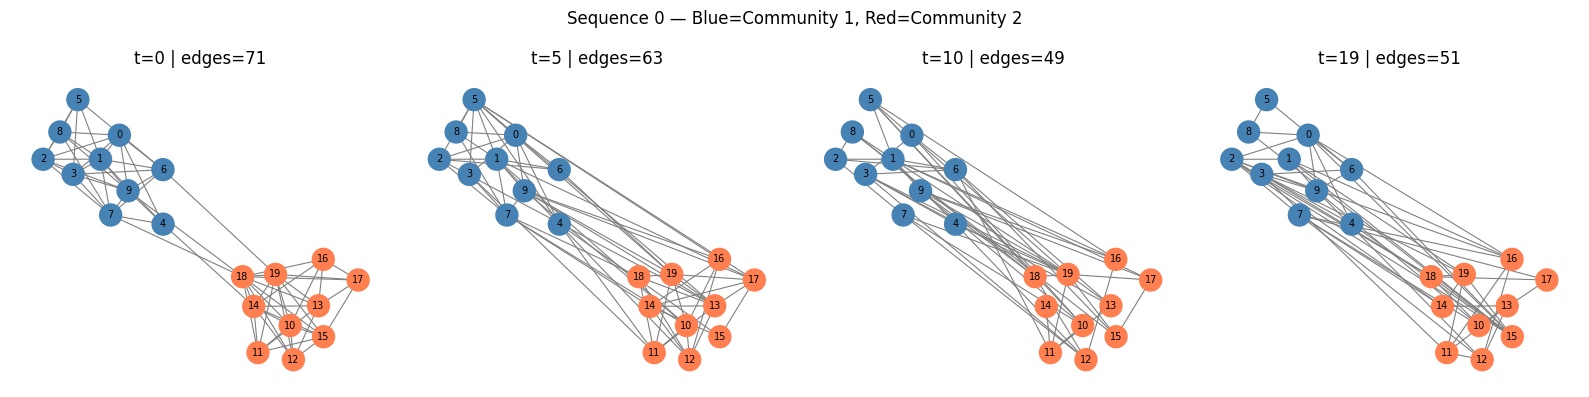

In [9]:
# Graph snapshots from sequence 0
pos = nx.spring_layout(seq0[0], seed=SEED)
timesteps_to_plot = [0, 5, 10, 19]
colors = ['steelblue'] * 10 + ['coral'] * 10  # colour the two communities

# Separate figure for graph snapshots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, t in zip(axes, timesteps_to_plot):
    nx.draw(
        seq0[t], pos=pos, ax=ax,
        node_color=colors, node_size=250,
        edge_color='gray', width=0.8,
        with_labels=True, font_size=7
    )
    ax.set_title(f"t={t} | edges={seq0[t].number_of_edges()}")

plt.suptitle("Sequence 0 — Blue=Community 1, Red=Community 2", fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
import torch.nn as nn # type: ignore
from torch_geometric.nn import GCNConv, global_mean_pool # type: ignore

class GCNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, latent_dim):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.fc = nn.Linear(hidden_channels, latent_dim)
        self.relu = nn.ReLU()

    def forward(self, x, edge_index, batch):
        h = self.relu(self.conv1(x, edge_index))
        h = self.relu(self.conv2(h, edge_index))
        h = global_mean_pool(h, batch)  # [batch_size, hidden_channels]
        z = self.fc(h)  # [batch_size, latent_dim]
        return z

In [11]:
class MLPDecoder(nn.Module):
    def __init__(self, latent_dim, n_nodes, hidden_dim):
        super().__init__()
        self.n_nodes = n_nodes
        self.n_edges = n_nodes * (n_nodes - 1) // 2  # undirected, no self-loops
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, self.n_edges),
            nn.Sigmoid()
        )

    def forward(self, z):
        edge_probs = self.net(z)  # [batch_size, n_edges]
        B = z.size(0)
        N = self.n_nodes
        adj = torch.zeros((B, N, N), device=z.device)
        idx = torch.triu_indices(N, N, offset=1)
        adj[:, idx[0], idx[1]] = edge_probs
        adj[:, idx[1], idx[0]] = edge_probs  # symmetric
        return adj

In [12]:
from torch_geometric.data import Batch # type: ignore

IN_CHANNELS = 1
HIDDEN_CHANNELS = 32
LATENT_DIM = 16

encoder = GCNEncoder(IN_CHANNELS, HIDDEN_CHANNELS, LATENT_DIM)
decoder = MLPDecoder(LATENT_DIM, N_NODES, HIDDEN_CHANNELS)

sample_inputs = [all_pairs[i][0] for i in range(4)]
batch = Batch.from_data_list(sample_inputs)

print("Batch info")
print(f"  x shape         : {batch.x.shape}")        # [N_total, 1]
print(f"  edge_index shape: {batch.edge_index.shape}")
print(f"  batch vector    : {batch.batch.shape}")    # [N_total]

z = encoder(batch.x, batch.edge_index, batch.batch)
print(f"\nEncoder output")
print(f"  z shape: {z.shape}")   # should be [4, LATENT_DIM]

adj_pred = decoder(z)
print(f"\nDecoder output")
print(f"  adj_pred shape : {adj_pred.shape}")   # should be [4, 20, 20]
print(f"  value range    : [{adj_pred.min():.3f}, {adj_pred.max():.3f}]")
print(f"  is symmetric   : {torch.allclose(adj_pred, adj_pred.transpose(1,2))}")

Batch info
  x shape         : torch.Size([80, 1])
  edge_index shape: torch.Size([2, 514])
  batch vector    : torch.Size([80])

Encoder output
  z shape: torch.Size([4, 16])

Decoder output
  adj_pred shape : torch.Size([4, 20, 20])
  value range    : [0.000, 0.641]
  is symmetric   : True


In [13]:
class MLPTransition(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )

    def forward(self, z):
        return self.net(z)

In [14]:
class KoopmanTransition(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.K = nn.Parameter(
            torch.randn(latent_dim, latent_dim) * 0.1
        )

    def forward(self, z):
        return z @ self.K.T

    def spectral_penalty(self):
        eigenvalues = torch.linalg.eigvals(self.K)
        magnitudes = torch.abs(eigenvalues)
        penalty = torch.relu(magnitudes - 1.0).mean()
        return penalty

In [15]:
mlp_transition      = MLPTransition(LATENT_DIM, HIDDEN_CHANNELS)
koopman_transition  = KoopmanTransition(LATENT_DIM)

# Use the z we already computed in Cell 7 (shape: [4, 16])
z_next_mlp     = mlp_transition(z)
z_next_koopman = koopman_transition(z)

print("MLP Transition")
print(f"  Input  z shape : {z.shape}")
print(f"  Output z shape : {z_next_mlp.shape}")

print("\nKoopman Transition")
print(f"  Input  z shape : {z.shape}")
print(f"  Output z shape : {z_next_koopman.shape}")
print(f"  K matrix shape : {koopman_transition.K.shape}")

# Check eigenvalue magnitudes before training
eigvals     = torch.linalg.eigvals(koopman_transition.K)
magnitudes  = torch.abs(eigvals)
print(f"\n  Eigenvalue magnitudes (before training):")
print(f"    min : {magnitudes.min().item():.4f}")
print(f"    max : {magnitudes.max():.4f}")
print(f"    mean: {magnitudes.mean():.4f}")
print(f"\n  Spectral penalty (before training): "
      f"{koopman_transition.spectral_penalty().item():.4f}")

# Count parameters in each model
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nParameter count")
print(f"  Encoder           : {count_params(encoder):,}")
print(f"  Decoder           : {count_params(decoder):,}")
print(f"  MLP Transition    : {count_params(mlp_transition):,}")
print(f"  Koopman Transition: {count_params(koopman_transition):,}")

MLP Transition
  Input  z shape : torch.Size([4, 16])
  Output z shape : torch.Size([4, 16])

Koopman Transition
  Input  z shape : torch.Size([4, 16])
  Output z shape : torch.Size([4, 16])
  K matrix shape : torch.Size([16, 16])

  Eigenvalue magnitudes (before training):
    min : 0.0597
    max : 0.3690
    mean: 0.2667

  Spectral penalty (before training): 0.0000

Parameter count
  Encoder           : 1,648
  Decoder           : 6,814
  MLP Transition    : 2,128
  Koopman Transition: 256


In [16]:
from torch_geometric.utils import to_dense_adj # type: ignore

def compute_loss(encoder, transition, decoder, batch_input, batch_target, n_nodes, spectral_weight=0.1, pos_weight_val=None):
    """Computes total loss (reconstruction + spectral penalty if applicable)."""
    z_t = encoder(batch_input.x, batch_input.edge_index, batch_input.batch)
    z_t1_pred = transition(z_t)
    adj_pred = decoder(z_t1_pred)

    adj_true = to_dense_adj(
        batch_target.edge_index,
        batch=batch_target.batch,
        max_num_nodes=n_nodes
    )

    idx = torch.triu_indices(n_nodes, n_nodes, offset=1)
    pred_flat = adj_pred[:, idx[0], idx[1]]
    true_flat = adj_true[:, idx[0], idx[1]]

    if pos_weight_val is None:
        n_pos = true_flat.sum().clamp(min=1)
        n_neg = (1 - true_flat).sum().clamp(min=1)
        pos_weight_val = (n_neg / n_pos).detach()

    pos_weight = torch.tensor([pos_weight_val])
    pred_logits = torch.log(
        pred_flat.clamp(1e-6, 1 - 1e-6) /
        (1 - pred_flat).clamp(1e-6, 1 - 1e-6)
    )

    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    loss_recon = loss_fn(pred_logits, true_flat)

    if hasattr(transition, 'spectral_penalty'):
        loss_spectral = transition.spectral_penalty()
        total_loss = loss_recon + spectral_weight * loss_spectral
    else:
        total_loss = loss_recon
    return total_loss, loss_recon

In [17]:
from torch.utils.data import DataLoader # type: ignore
from torch_geometric.data import Batch # type: ignore
import random

def train_model(transition_model, n_epochs = 100, batch_size = 32,
                lr = 1e-3, spectral_weight = 0.01, seed = 42, latent_dim = LATENT_DIM):
    """Trains encoder, decoder, and transition models on graph pairs."""
    torch.manual_seed(seed)
    random.seed(seed)

    enc = GCNEncoder(IN_CHANNELS, HIDDEN_CHANNELS, latent_dim)
    dec = MLPDecoder(latent_dim, N_NODES, HIDDEN_CHANNELS)
    trans = transition_model

    optimizer = torch.optim.Adam(
        list(enc.parameters()) + list(dec.parameters()) + list(trans.parameters()),
        lr=lr
    )

    loss_history = []
    pairs_shuffled = all_pairs.copy()

    for epoch in range(n_epochs):
        random.shuffle(pairs_shuffled)
        epoch_losses = []

        for start in range(0, len(pairs_shuffled), batch_size):
            batch_pairs = pairs_shuffled[start:start + batch_size]
            if len(batch_pairs) == 0: continue

            batch_input = Batch.from_data_list([p[0] for p in batch_pairs])
            batch_target = Batch.from_data_list([p[1] for p in batch_pairs])

            optimizer.zero_grad()
            loss, recon_loss = compute_loss(
                enc, trans, dec, batch_input, batch_target, N_NODES,
                spectral_weight=spectral_weight
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(enc.parameters()) + list(dec.parameters()) + list(trans.parameters()),
                max_norm=1.0
            )
            optimizer.step()
            epoch_losses.append(recon_loss.item())

        avg_loss = sum(epoch_losses) / len(epoch_losses)
        loss_history.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} | Recon Loss: {avg_loss:.4f}")

    return enc, dec, trans, loss_history

In [18]:
# ----- Train MLP model -----
print("Training MLP Transition Model")
mlp_trans = MLPTransition(LATENT_DIM, HIDDEN_CHANNELS)
enc_mlp, dec_mlp, mlp_trans, losses_mlp = train_model(mlp_trans)

# ----- Train Koopman model -----
print("\nTraining Koopman Transition Model")
koop_trans = KoopmanTransition(LATENT_DIM)
enc_koop, dec_koop, koop_trans, losses_koop = train_model(koop_trans)

Training MLP Transition Model
Epoch  10/100 | Recon Loss: 0.9409
Epoch  20/100 | Recon Loss: 0.9203
Epoch  30/100 | Recon Loss: 0.9181
Epoch  40/100 | Recon Loss: 0.9157
Epoch  50/100 | Recon Loss: 0.9157
Epoch  60/100 | Recon Loss: 0.9139
Epoch  70/100 | Recon Loss: 0.9149
Epoch  80/100 | Recon Loss: 0.9130
Epoch  90/100 | Recon Loss: 0.9128
Epoch 100/100 | Recon Loss: 0.9119

Training Koopman Transition Model
Epoch  10/100 | Recon Loss: 0.9421
Epoch  20/100 | Recon Loss: 0.9202
Epoch  30/100 | Recon Loss: 0.9187
Epoch  40/100 | Recon Loss: 0.9160
Epoch  50/100 | Recon Loss: 0.9160
Epoch  60/100 | Recon Loss: 0.9140
Epoch  70/100 | Recon Loss: 0.9149
Epoch  80/100 | Recon Loss: 0.9131
Epoch  90/100 | Recon Loss: 0.9131
Epoch 100/100 | Recon Loss: 0.9126


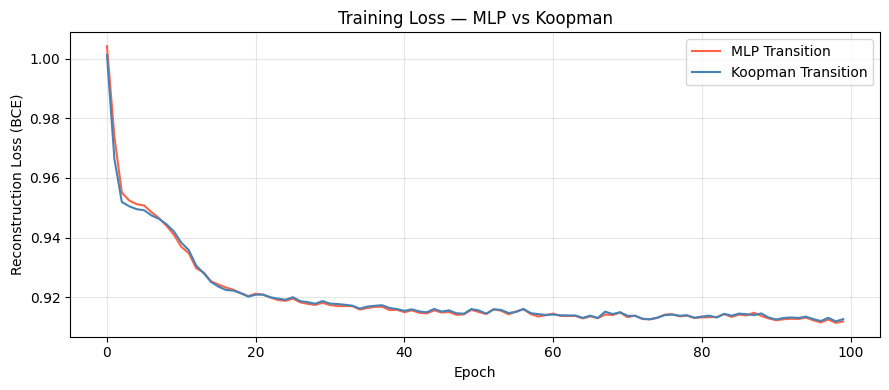

Final loss — MLP    : 0.9119
Final loss — Koopman: 0.9126


In [19]:
plt.figure(figsize=(9, 4))
plt.plot(losses_mlp,   label='MLP Transition',     color='tomato')
plt.plot(losses_koop,  label='Koopman Transition',  color='steelblue')
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (BCE)")
plt.title("Training Loss — MLP vs Koopman")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final loss — MLP    : {losses_mlp[-1]:.4f}")
print(f"Final loss — Koopman: {losses_koop[-1]:.4f}")

In [20]:
sample_in, sample_tgt = all_pairs[0]

batch_in  = Batch.from_data_list([sample_in])
batch_tgt = Batch.from_data_list([sample_tgt])

# Get prediction from Koopman model
enc_koop.eval()
dec_koop.eval()
koop_trans.eval()

with torch.no_grad():
    z       = enc_koop(batch_in.x, batch_in.edge_index, batch_in.batch)
    z_next  = koop_trans(z)
    adj_pred = dec_koop(z_next)                       # [1, 20, 20]

# Ground truth adjacency
adj_true = to_dense_adj(
    batch_tgt.edge_index,
    batch=batch_tgt.batch,
    max_num_nodes=N_NODES
)                                                      # [1, 20, 20]

# Threshold at 0.5 → binary prediction
adj_binary = (adj_pred > 0.5).float()

idx       = torch.triu_indices(N_NODES, N_NODES, offset=1)
pred_flat = adj_binary[0, idx[0], idx[1]]
true_flat = adj_true[0,  idx[0], idx[1]]

n_true_edges  = true_flat.sum().item()
n_pred_edges  = pred_flat.sum().item()
n_correct     = (pred_flat == true_flat).sum().item()
accuracy      = n_correct / len(true_flat) * 100

print(f"True edges predicted : {n_true_edges:.0f}")
print(f"Predicted edges      : {n_pred_edges:.0f}")
print(f"Edge-level accuracy  : {accuracy:.1f}%")
print(f"\n(Baseline — predict no edges: "
      f"{(1 - true_flat).sum().item() / len(true_flat) * 100:.1f}%)")

True edges predicted : 62
Predicted edges      : 71
Edge-level accuracy  : 88.9%

(Baseline — predict no edges: 67.4%)


In [21]:
def multi_step_rollout(encoder, transition, decoder, sequence, n_nodes, n_steps):
    encoder.eval()
    transition.eval()
    decoder.eval()

    accuracies = []
    f1_scores   = []

    with torch.no_grad():
        g0 = Batch.from_data_list([sequence[0]])
        z = encoder(g0.x, g0.edge_index, g0.batch)

        for step in range(1, n_steps + 1):
            z = transition(z)

            adj_pred = decoder(z)
            adj_binary = (adj_pred > 0.5).float()

            g_true = Batch.from_data_list([sequence[step]])
            adj_true = to_dense_adj(
                g_true.edge_index,
                batch=g_true.batch,
                max_num_nodes=n_nodes
            )

            idx = torch.triu_indices(n_nodes, n_nodes, offset=1)
            pred_flat = adj_binary[0, idx[0], idx[1]]
            true_flat = adj_true[0,  idx[0], idx[1]]

            accuracy = (pred_flat == true_flat).float().mean().item()
            accuracies.append(accuracy)

            tp = (pred_flat * true_flat).sum().item()
            fp = (pred_flat * (1 - true_flat)).sum().item()
            fn = ((1 - pred_flat) * true_flat).sum().item()
            precision = tp / (tp + fp + 1e-8)
            recall = tp / (tp + fn + 1e-8)
            f1 = 2 * precision * recall / (precision + recall + 1e-8)
            f1_scores.append(f1)
    return accuracies, f1_scores

In [22]:
EVAL_SEQS  = all_sequences[-10:]   # last 10 sequences
N_STEPS    = 15                    # roll out 15 steps

# Convert NetworkX sequences to PyG
def seq_to_pyg(sequence, n_nodes):
    return [graph_to_pyg(G, n_nodes) for G in sequence]

mlp_accs_all   = []
mlp_f1s_all    = []
koop_accs_all  = []
koop_f1s_all   = []

for seq in EVAL_SEQS:
    pyg_seq = seq_to_pyg(seq, N_NODES)

    accs, f1s = multi_step_rollout(
        enc_mlp, mlp_trans, dec_mlp, pyg_seq, N_NODES, N_STEPS
    )
    mlp_accs_all.append(accs)
    mlp_f1s_all.append(f1s)

    accs, f1s = multi_step_rollout(
        enc_koop, koop_trans, dec_koop, pyg_seq, N_NODES, N_STEPS
    )
    koop_accs_all.append(accs)
    koop_f1s_all.append(f1s)

# Average across sequences
import numpy as np # type: ignore
mlp_accs_mean   = np.mean(mlp_accs_all,  axis=0)
mlp_f1s_mean    = np.mean(mlp_f1s_all,   axis=0)
koop_accs_mean  = np.mean(koop_accs_all, axis=0)
koop_f1s_mean   = np.mean(koop_f1s_all,  axis=0)

steps = list(range(1, N_STEPS + 1))

print(f"{'Step':<6} {'MLP Acc':>10} {'Koop Acc':>10} "
      f"{'MLP F1':>10} {'Koop F1':>10}")
for i, s in enumerate(steps):
    print(f"{s:<6} {mlp_accs_mean[i]:>10.3f} "
          f"{koop_accs_mean[i]:>10.3f} "
          f"{mlp_f1s_mean[i]:>10.3f} "
          f"{koop_f1s_mean[i]:>10.3f}")

Step      MLP Acc   Koop Acc     MLP F1    Koop F1
1           0.913      0.913      0.878      0.878
2           0.702      0.571      0.480      0.377
3           0.577      0.667      0.326      0.322
4           0.556      0.701      0.299      0.459
5           0.558      0.668      0.314      0.403
6           0.564      0.653      0.331      0.359
7           0.569      0.651      0.345      0.336
8           0.561      0.663      0.319      0.330
9           0.566      0.660      0.327      0.322
10          0.558      0.657      0.321      0.325
11          0.549      0.651      0.312      0.321
12          0.549      0.651      0.301      0.307
13          0.561      0.657      0.326      0.326
14          0.558      0.652      0.329      0.326
15          0.554      0.649      0.331      0.332


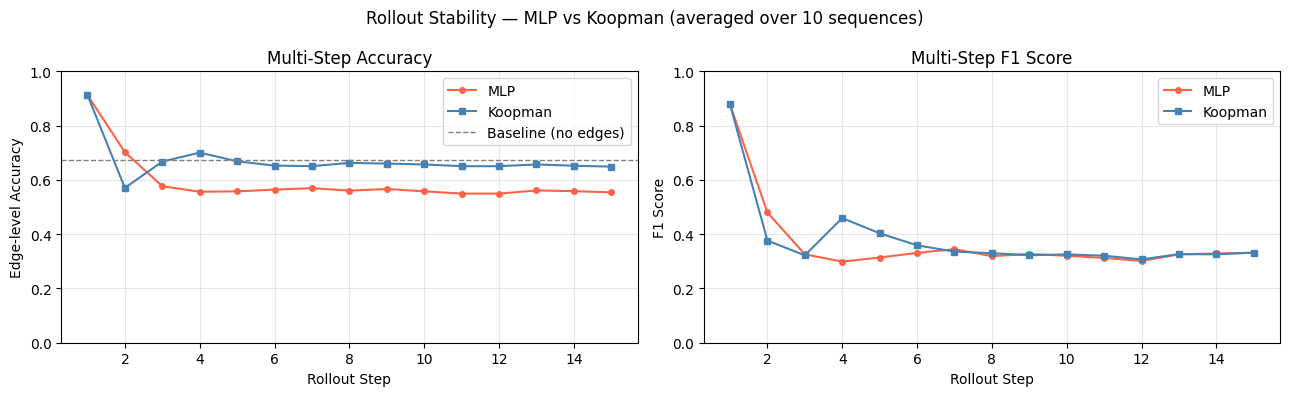


Summary (averaged over 10 eval sequences)
                  MLP   Koopman
Step-1  Acc:    0.913     0.913
Step-5  Acc:    0.558     0.668
Step-15 Acc:    0.554     0.649
Step-1  F1 :    0.878     0.878
Step-5  F1 :    0.314     0.403
Step-15 F1 :    0.331     0.332


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: Edge-level accuracy over steps
axes[0].plot(steps, mlp_accs_mean,
             label='MLP',     color='tomato',    marker='o', markersize=4)
axes[0].plot(steps, koop_accs_mean,
             label='Koopman', color='steelblue', marker='s', markersize=4)
axes[0].axhline(y=0.674, color='gray', linestyle='--',
                linewidth=1, label='Baseline (no edges)')
axes[0].set_xlabel("Rollout Step")
axes[0].set_ylabel("Edge-level Accuracy")
axes[0].set_title("Multi-Step Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1)

# Plot 2: F1 score over steps
axes[1].plot(steps, mlp_f1s_mean,
             label='MLP',     color='tomato',    marker='o', markersize=4)
axes[1].plot(steps, koop_f1s_mean,
             label='Koopman', color='steelblue', marker='s', markersize=4)
axes[1].set_xlabel("Rollout Step")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Multi-Step F1 Score")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1)

plt.suptitle("Rollout Stability — MLP vs Koopman (averaged over 10 sequences)",
             fontsize=12)
plt.tight_layout()
plt.show()

# Summary statistics
print("\nSummary (averaged over 10 eval sequences)")
print(f"             {'MLP':>8}  {'Koopman':>8}")
print(f"Step-1  Acc: {mlp_accs_mean[0]:>8.3f}  {koop_accs_mean[0]:>8.3f}")
print(f"Step-5  Acc: {mlp_accs_mean[4]:>8.3f}  {koop_accs_mean[4]:>8.3f}")
print(f"Step-15 Acc: {mlp_accs_mean[14]:>8.3f}  {koop_accs_mean[14]:>8.3f}")
print(f"Step-1  F1 : {mlp_f1s_mean[0]:>8.3f}  {koop_f1s_mean[0]:>8.3f}")
print(f"Step-5  F1 : {mlp_f1s_mean[4]:>8.3f}  {koop_f1s_mean[4]:>8.3f}")
print(f"Step-15 F1 : {mlp_f1s_mean[14]:>8.3f}  {koop_f1s_mean[14]:>8.3f}")

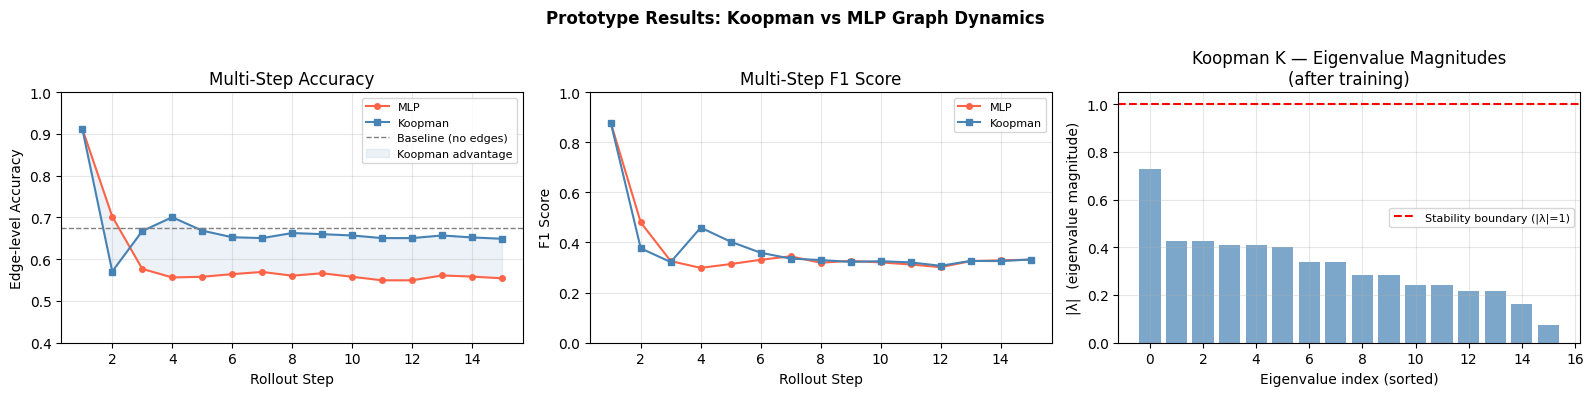

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(steps, mlp_accs_mean,
             label='MLP',     color='tomato',    marker='o', markersize=4)
axes[0].plot(steps, koop_accs_mean,
             label='Koopman', color='steelblue', marker='s', markersize=4)
axes[0].axhline(y=0.674, color='gray', linestyle='--',
                linewidth=1, label='Baseline (no edges)')
axes[0].fill_between(steps, mlp_accs_mean, koop_accs_mean,
                     alpha=0.1, color='steelblue',
                     label='Koopman advantage')
axes[0].set_xlabel("Rollout Step")
axes[0].set_ylabel("Edge-level Accuracy")
axes[0].set_title("Multi-Step Accuracy")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0.4, 1.0)

axes[1].plot(steps, mlp_f1s_mean,
             label='MLP',     color='tomato',    marker='o', markersize=4)
axes[1].plot(steps, koop_f1s_mean,
             label='Koopman', color='steelblue', marker='s', markersize=4)
axes[1].set_xlabel("Rollout Step")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Multi-Step F1 Score")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.0)

eigvals    = torch.linalg.eigvals(koop_trans.K)
magnitudes = torch.abs(eigvals).detach().numpy()

axes[2].bar(range(len(magnitudes)), sorted(magnitudes, reverse=True),
            color='steelblue', alpha=0.7)
axes[2].axhline(y=1.0, color='red', linestyle='--',
                linewidth=1.5, label='Stability boundary (|λ|=1)')
axes[2].set_xlabel("Eigenvalue index (sorted)")
axes[2].set_ylabel("|λ|  (eigenvalue magnitude)")
axes[2].set_title("Koopman K — Eigenvalue Magnitudes\n(after training)")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle("Prototype Results: Koopman vs MLP Graph Dynamics",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
def run_single_seed(seed, latent_dim, n_epochs=100):
    """
    Runs the full pipeline — data generation, training, and
    evaluation — for a single random seed.
    """
    # ---- Reproducibility ----
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)

    # ---- Fresh dataset for this seed ----
    seqs, pairs = generate_dataset(
        N_SEQ, N_NODES, BLOCK_SIZES,
        P_INTRA, P_INTER, P_REMOVE, P_ADD, T
    )

    # ---- Train MLP ----
    mlp_t = MLPTransition(latent_dim, HIDDEN_CHANNELS)
    enc_m, dec_m, mlp_t, _ = train_model(
        mlp_t, n_epochs=n_epochs,
        batch_size=32, lr=1e-3, seed=seed, latent_dim=latent_dim
    )

    # ---- Train Koopman ----
    koop_t = KoopmanTransition(latent_dim)
    enc_k, dec_k, koop_t, _ = train_model(
        koop_t, n_epochs=n_epochs,
        batch_size=32, lr=1e-3, seed=seed, latent_dim=latent_dim
    )

    # ---- Evaluate on held-out sequences ----
    eval_seqs = seqs[-10:]
    mlp_accs, mlp_f1s   = [], []
    koop_accs, koop_f1s = [], []

    for seq in eval_seqs:
        pyg_seq = seq_to_pyg(seq, N_NODES)

        a, f = multi_step_rollout(enc_m, mlp_t,  dec_m, pyg_seq, N_NODES, N_STEPS)
        mlp_accs.append(a);  mlp_f1s.append(f)

        a, f = multi_step_rollout(enc_k, koop_t, dec_k, pyg_seq, N_NODES, N_STEPS)
        koop_accs.append(a); koop_f1s.append(f)

    return {
        'mlp'    : {'accs': np.mean(mlp_accs,  axis=0),
                    'f1s' : np.mean(mlp_f1s,   axis=0)},
        'koopman': {'accs': np.mean(koop_accs, axis=0),
                    'f1s' : np.mean(koop_f1s,  axis=0)}
    }

SEEDS     = [42, 7, 123, 256, 999]
N_STEPS   = 15
all_results = []

for i, seed in enumerate(SEEDS):
    print(f"Seed {seed}  ({i+1}/{len(SEEDS)}) ...", end=' ')
    result = run_single_seed(seed, LATENT_DIM)
    all_results.append(result)
    print(f"done | MLP step-15 acc: {result['mlp']['accs'][-1]:.3f}"
          f" | Koop step-15 acc: {result['koopman']['accs'][-1]:.3f}")

print("\nAll seeds complete")

Seed 42  (1/5) ... Epoch  10/100 | Recon Loss: 0.9416
Epoch  20/100 | Recon Loss: 0.9187
Epoch  30/100 | Recon Loss: 0.9168
Epoch  40/100 | Recon Loss: 0.9153
Epoch  50/100 | Recon Loss: 0.9159
Epoch  60/100 | Recon Loss: 0.9134
Epoch  70/100 | Recon Loss: 0.9141
Epoch  80/100 | Recon Loss: 0.9126
Epoch  90/100 | Recon Loss: 0.9128
Epoch 100/100 | Recon Loss: 0.9121
Epoch  10/100 | Recon Loss: 0.9421
Epoch  20/100 | Recon Loss: 0.9202
Epoch  30/100 | Recon Loss: 0.9187
Epoch  40/100 | Recon Loss: 0.9160
Epoch  50/100 | Recon Loss: 0.9160
Epoch  60/100 | Recon Loss: 0.9140
Epoch  70/100 | Recon Loss: 0.9149
Epoch  80/100 | Recon Loss: 0.9131
Epoch  90/100 | Recon Loss: 0.9131
Epoch 100/100 | Recon Loss: 0.9126
done | MLP step-15 acc: 0.631 | Koop step-15 acc: 0.649
Seed 7  (2/5) ... Epoch  10/100 | Recon Loss: 0.9435
Epoch  20/100 | Recon Loss: 0.9197
Epoch  30/100 | Recon Loss: 0.9177
Epoch  40/100 | Recon Loss: 0.9160
Epoch  50/100 | Recon Loss: 0.9156
Epoch  60/100 | Recon Loss: 0.91

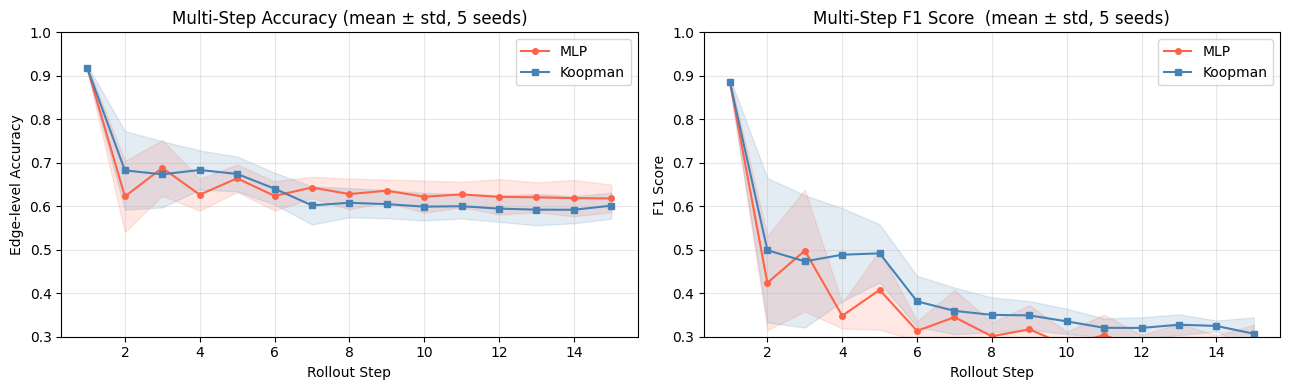

MULTI-SEED RESULTS (5 seeds)

Metric                                    MLP         Koopman
Step-1  Accuracy                   0.917±0.007  0.917±0.007
Step-5  Accuracy                   0.664±0.032  0.674±0.040
Step-10 Accuracy                   0.622±0.037  0.599±0.032
Step-15 Accuracy                   0.618±0.032  0.601±0.030
Step-1  F1                         0.885±0.010  0.885±0.010
Step-5  F1                         0.408±0.091  0.492±0.067
Step-10 F1                         0.280±0.032  0.335±0.029
Step-15 F1                         0.285±0.042  0.307±0.037

Paired t-test (step-15 accuracy):
t-statistic: -1.4332
p-value: 0.2251
Result: Difference not yet significant (p = 0.225)


In [26]:
# Stack results across seeds → shape [n_seeds, n_steps]
mlp_accs_seeds  = np.array([r['mlp']['accs']     for r in all_results])
mlp_f1s_seeds   = np.array([r['mlp']['f1s']      for r in all_results])
koop_accs_seeds = np.array([r['koopman']['accs'] for r in all_results])
koop_f1s_seeds  = np.array([r['koopman']['f1s']  for r in all_results])

# Mean and std across seeds
mlp_acc_mean   = mlp_accs_seeds.mean(axis=0)
mlp_acc_std    = mlp_accs_seeds.std(axis=0)
koop_acc_mean  = koop_accs_seeds.mean(axis=0)
koop_acc_std   = koop_accs_seeds.std(axis=0)

mlp_f1_mean    = mlp_f1s_seeds.mean(axis=0)
mlp_f1_std     = mlp_f1s_seeds.std(axis=0)
koop_f1_mean   = koop_f1s_seeds.mean(axis=0)
koop_f1_std    = koop_f1s_seeds.std(axis=0)

steps = np.arange(1, N_STEPS + 1)

# ---- Plot with confidence bands ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (m_mean, m_std, k_mean, k_std), ylabel, title in zip(
    axes,
    [(mlp_acc_mean, mlp_acc_std, koop_acc_mean, koop_acc_std),
     (mlp_f1_mean,  mlp_f1_std,  koop_f1_mean,  koop_f1_std)],
    ['Edge-level Accuracy', 'F1 Score'],
    ['Multi-Step Accuracy (mean ± std, 5 seeds)',
     'Multi-Step F1 Score  (mean ± std, 5 seeds)']
):
    # Mean lines
    ax.plot(steps, m_mean, color='tomato',    label='MLP',
            marker='o', markersize=4)
    ax.plot(steps, k_mean, color='steelblue', label='Koopman',
            marker='s', markersize=4)

    # Shaded ± 1 std bands
    # fill_between draws a shaded region between (mean - std)
    # and (mean + std) — this shows how much results vary
    # across different random seeds
    ax.fill_between(steps,
                    m_mean - m_std, m_mean + m_std,
                    alpha=0.15, color='tomato')
    ax.fill_between(steps,
                    k_mean - k_std, k_mean + k_std,
                    alpha=0.15, color='steelblue')

    ax.set_xlabel("Rollout Step")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(0.3, 1.0)

plt.tight_layout()
plt.show()

# ---- Statistical significance — paired t-test ----
# We compare step-15 accuracy across seeds:
#   H0 (null hypothesis)     : MLP and Koopman are the same
#   H1 (alternate hypothesis): Koopman is better
#
# Reference: scipy.stats.ttest_rel
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html

from scipy import stats

# Compare step-15 accuracy across 5 seeds
mlp_step15  = mlp_accs_seeds[:, -1]   # shape [5]
koop_step15 = koop_accs_seeds[:, -1]  # shape [5]

t_stat, p_value = stats.ttest_rel(koop_step15, mlp_step15)

print("MULTI-SEED RESULTS (5 seeds)")
print(f"\n{'Metric':<30} {'MLP':>14}  {'Koopman':>14}")

for step in [1, 5, 10, 15]:
    i = step - 1
    print(f"Step-{step:<2} Accuracy{'':<19}"
          f"{mlp_acc_mean[i]:.3f}±{mlp_acc_std[i]:.3f}"
          f"  {koop_acc_mean[i]:.3f}±{koop_acc_std[i]:.3f}")

for step in [1, 5, 10, 15]:
    i = step - 1
    print(f"Step-{step:<2} F1{'':<25}"
          f"{mlp_f1_mean[i]:.3f}±{mlp_f1_std[i]:.3f}"
          f"  {koop_f1_mean[i]:.3f}±{koop_f1_std[i]:.3f}")

print(f"\n{'Paired t-test (step-15 accuracy):'}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    print(f"Result: Koopman is significantly better (p < 0.05)")
elif p_value < 0.10:
    print(f"Result: Trend favours Koopman (p < 0.10) — needs more seeds")
else:
    print(f"Result: Difference not yet significant (p = {p_value:.3f})")

In [27]:
def run_ablation(latent_dim, seeds, n_epochs=100):
    """Evaluates MLP and Koopman models across different random seeds for a given latent dimension."""
    mlp_accs_all, koop_accs_all = [], []
    mlp_f1s_all, koop_f1s_all = [], []

    for seed in seeds:
        np.random.seed(seed)
        torch.manual_seed(seed)
        random.seed(seed)

        # Dataset generation
        seqs, pairs = generate_dataset(
            N_SEQ, N_NODES, BLOCK_SIZES,
            P_INTRA, P_INTER, P_REMOVE, P_ADD, T
        )

        # Train models
        mlp_t = MLPTransition(latent_dim, HIDDEN_CHANNELS)
        enc_m, dec_m, mlp_t, _ = train_model(
            mlp_t, n_epochs=n_epochs, seed=seed, latent_dim=latent_dim
        )

        koop_t = KoopmanTransition(latent_dim)
        enc_k, dec_k, koop_t, _ = train_model(
            koop_t, n_epochs=n_epochs, seed=seed, latent_dim=latent_dim
        )

        # Rollout evaluation
        eval_seqs = seqs[-10:]
        m_accs, m_f1s = [], []
        k_accs, k_f1s = [], []

        for seq in eval_seqs:
            pyg_seq = seq_to_pyg(seq, N_NODES)
            a_m, f_m = multi_step_rollout(enc_m, mlp_t, dec_m, pyg_seq, N_NODES, N_STEPS)
            a_k, f_k = multi_step_rollout(enc_k, koop_t, dec_k, pyg_seq, N_NODES, N_STEPS)
            m_accs.append(a_m); m_f1s.append(f_m)
            k_accs.append(a_k); k_f1s.append(f_k)

        mlp_accs_all.append(np.mean(m_accs, axis=0))
        mlp_f1s_all.append(np.mean(m_f1s, axis=0))
        koop_accs_all.append(np.mean(k_accs, axis=0))
        koop_f1s_all.append(np.mean(k_f1s, axis=0))

    return {
        'mlp': {
            'acc_mean': np.mean(mlp_accs_all, axis=0), 'acc_std': np.std(mlp_accs_all, axis=0),
            'f1_mean': np.mean(mlp_f1s_all, axis=0), 'f1_std': np.std(mlp_f1s_all, axis=0),
        },
        'koopman': {
            'acc_mean': np.mean(koop_accs_all, axis=0), 'acc_std': np.std(koop_accs_all, axis=0),
            'f1_mean': np.mean(koop_f1s_all, axis=0), 'f1_std': np.std(koop_f1s_all, axis=0),
        }
    }

SEEDS = [42, 7, 123, 256, 999]
DIMS = [16, 32, 64]
ablation_results = {}

for dim in DIMS:
    print(f"\nLatent dim = {dim}\n")
    ablation_results[dim] = run_ablation(dim, SEEDS)
    r = ablation_results[dim]
    print(f"Step-5 F1 -> MLP: {r['mlp']['f1_mean'][4]:.3f} Koopman: {r['koopman']['f1_mean'][4]:.3f}")
    print(f"Step-15 F1 -> MLP: {r['mlp']['f1_mean'][14]:.3f} Koopman: {r['koopman']['f1_mean'][14]:.3f}")


Latent dim = 16

Epoch  10/100 | Recon Loss: 0.9416
Epoch  20/100 | Recon Loss: 0.9187
Epoch  30/100 | Recon Loss: 0.9168
Epoch  40/100 | Recon Loss: 0.9153
Epoch  50/100 | Recon Loss: 0.9159
Epoch  60/100 | Recon Loss: 0.9134
Epoch  70/100 | Recon Loss: 0.9141
Epoch  80/100 | Recon Loss: 0.9126
Epoch  90/100 | Recon Loss: 0.9128
Epoch 100/100 | Recon Loss: 0.9121
Epoch  10/100 | Recon Loss: 0.9421
Epoch  20/100 | Recon Loss: 0.9202
Epoch  30/100 | Recon Loss: 0.9187
Epoch  40/100 | Recon Loss: 0.9160
Epoch  50/100 | Recon Loss: 0.9160
Epoch  60/100 | Recon Loss: 0.9140
Epoch  70/100 | Recon Loss: 0.9149
Epoch  80/100 | Recon Loss: 0.9131
Epoch  90/100 | Recon Loss: 0.9131
Epoch 100/100 | Recon Loss: 0.9126
Epoch  10/100 | Recon Loss: 0.9435
Epoch  20/100 | Recon Loss: 0.9197
Epoch  30/100 | Recon Loss: 0.9177
Epoch  40/100 | Recon Loss: 0.9160
Epoch  50/100 | Recon Loss: 0.9156
Epoch  60/100 | Recon Loss: 0.9141
Epoch  70/100 | Recon Loss: 0.9138
Epoch  80/100 | Recon Loss: 0.9133
Ep

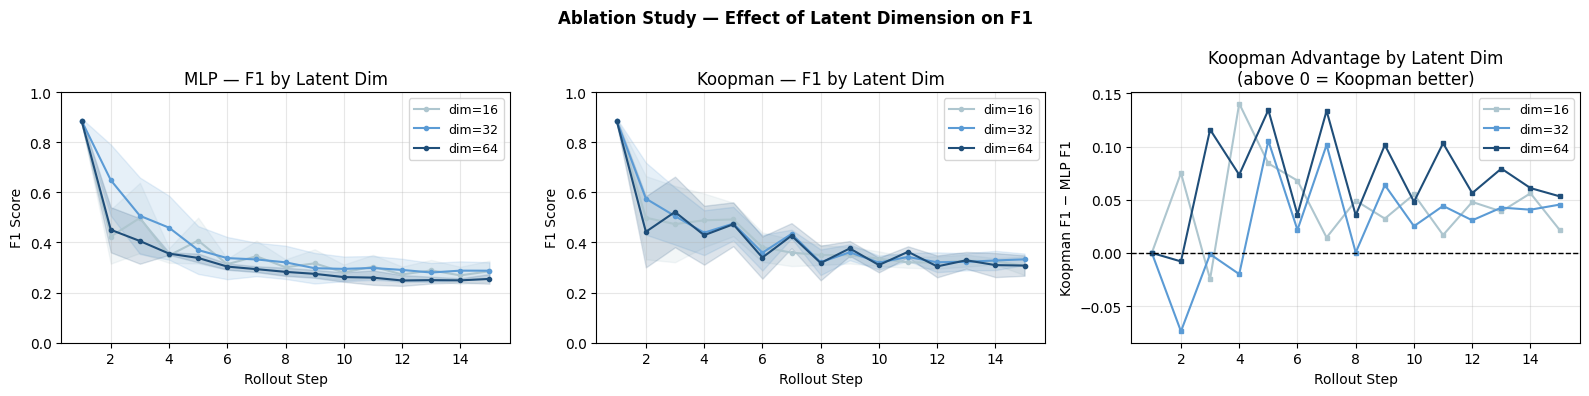


Dim    Model       Step-1 F1  Step-5 F1  Step-15 F1
16     mlp             0.885      0.408       0.285
16     koopman         0.885      0.492       0.307

32     mlp             0.885      0.370       0.287
32     koopman         0.885      0.475       0.333

64     mlp             0.885      0.338       0.255
64     koopman         0.885      0.473       0.308



In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors    = {16: '#aec6cf', 32: '#5b9bd5', 64: '#1f4e79'}

for ax, model in zip(axes[:2], ['mlp', 'koopman']):
    for dim in DIMS:
        r        = ablation_results[dim]
        f1_mean  = r[model]['f1_mean']
        f1_std   = r[model]['f1_std']

        ax.plot(steps, f1_mean, label=f'dim={dim}',
                color=colors[dim], marker='o', markersize=3)
        ax.fill_between(steps,
                        f1_mean - f1_std,
                        f1_mean + f1_std,
                        alpha=0.15, color=colors[dim])

    ax.set_xlabel("Rollout Step")
    ax.set_ylabel("F1 Score")
    ax.set_title(f"{'MLP' if model=='mlp' else 'Koopman'} — F1 by Latent Dim")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.0)

ax = axes[2]
for dim in DIMS:
    r         = ablation_results[dim]
    advantage = r['koopman']['f1_mean'] - r['mlp']['f1_mean']
    ax.plot(steps, advantage, label=f'dim={dim}',
            color=colors[dim], marker='s', markersize=3)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel("Rollout Step")
ax.set_ylabel("Koopman F1 − MLP F1")
ax.set_title("Koopman Advantage by Latent Dim\n(above 0 = Koopman better)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle("Ablation Study — Effect of Latent Dimension on F1",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


print(f"\n{'Dim':<6} {'Model':<10} "
      f"{'Step-1 F1':>10} {'Step-5 F1':>10} {'Step-15 F1':>11}")
for dim in DIMS:
    r = ablation_results[dim]
    for model in ['mlp', 'koopman']:
        f1 = r[model]['f1_mean']
        print(f"{dim:<6} {model:<10} "
              f"{f1[0]:>10.3f} {f1[4]:>10.3f} {f1[14]:>11.3f}")
    print()

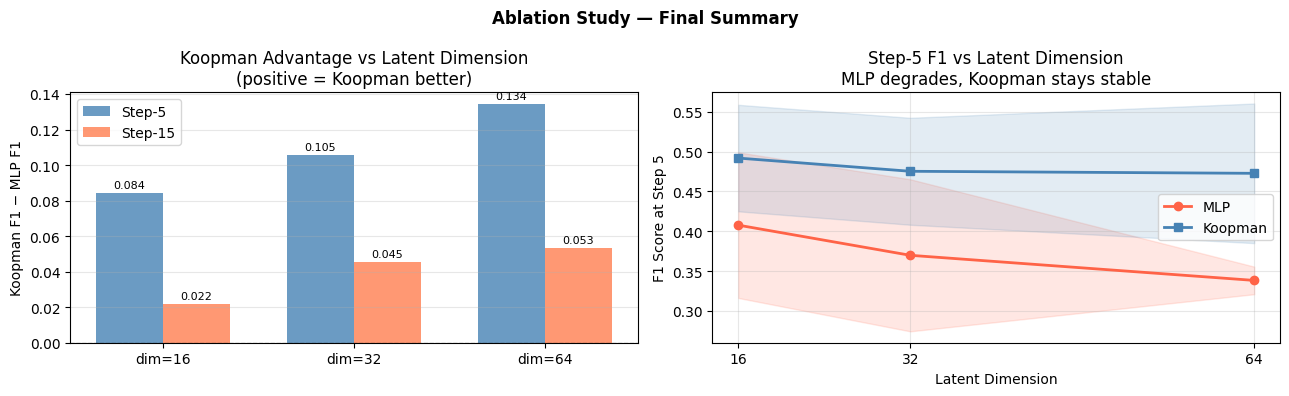

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

step5_advantages  = []
step15_advantages = []

for dim in DIMS:
    r = ablation_results[dim]
    step5_advantages.append(
        r['koopman']['f1_mean'][4] - r['mlp']['f1_mean'][4]
    )
    step15_advantages.append(
        r['koopman']['f1_mean'][14] - r['mlp']['f1_mean'][14]
    )

x     = np.arange(len(DIMS))
width = 0.35

bars1 = axes[0].bar(x - width/2, step5_advantages,  width,
                    label='Step-5',  color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + width/2, step15_advantages, width,
                    label='Step-15', color='coral',     alpha=0.8)

axes[0].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'dim={d}' for d in DIMS])
axes[0].set_ylabel("Koopman F1 − MLP F1")
axes[0].set_title("Koopman Advantage vs Latent Dimension\n"
                  "(positive = Koopman better)")
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')


for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=8)


mlp_step5   = [ablation_results[d]['mlp']['f1_mean'][4]     for d in DIMS]
koop_step5  = [ablation_results[d]['koopman']['f1_mean'][4] for d in DIMS]
mlp_step5_std  = [ablation_results[d]['mlp']['f1_std'][4]     for d in DIMS]
koop_step5_std = [ablation_results[d]['koopman']['f1_std'][4] for d in DIMS]

axes[1].plot(DIMS, mlp_step5,  color='tomato',    marker='o',
             label='MLP',     linewidth=2)
axes[1].plot(DIMS, koop_step5, color='steelblue', marker='s',
             label='Koopman', linewidth=2)
axes[1].fill_between(DIMS,
                     np.array(mlp_step5) - np.array(mlp_step5_std),
                     np.array(mlp_step5) + np.array(mlp_step5_std),
                     alpha=0.15, color='tomato')
axes[1].fill_between(DIMS,
                     np.array(koop_step5) - np.array(koop_step5_std),
                     np.array(koop_step5) + np.array(koop_step5_std),
                     alpha=0.15, color='steelblue')

axes[1].set_xlabel("Latent Dimension")
axes[1].set_ylabel("F1 Score at Step 5")
axes[1].set_title("Step-5 F1 vs Latent Dimension\n"
                  "MLP degrades, Koopman stays stable")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xticks(DIMS)

plt.suptitle("Ablation Study — Final Summary", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()